In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage
from agents.analyst import analyst_node
from agents.extended_analyst import extended_analyst_node
from graph.agent_state import AgentState

In [ ]:
from langgraph.types import interrupt

class TargetConfirmation(BaseModel):
    confirmed: bool = Field(description="Пользователь согласился с текущим значением")
    value: str = Field(description="Итоговое значение — либо текущее, либо новое от пользователя")

class IdColumnsConfirmation(BaseModel):
    confirmed: bool = Field(description="Пользователь согласился с текущим списком")
    value: list[str] = Field(description="Итоговый список колонок")

def first_hitl_analyst_node(state: AgentState) -> dict:
    
    # Вопрос 1 — таргет
    target_answer = interrupt({...})

    parsed = parse_target_llm.invoke({
        "current_value": state["analysis_result"].target_column,
        "user_input": target_answer
    })

    confirmed_target = parsed.value
    
    # Вопрос 2 — ID колонки
    id_answer = interrupt({
        "question": "Подтвердите колонки-идентификаторы для удаления",
        "current_value": state["extended_analysis"].id_columns,
        "hint": "Введите список через запятую или 'ok' для подтверждения"
    })
    
    # парсим ответы
    ...
    
    return {
        "confirmed_target": ...,
        "confirmed_id_columns": ...
    }

parse_target_llm = ChatPromptTemplate.from_messages([
    ("system", """
     Пользователь отвечает на вопрос о целевой колонке.
     Текущее значение: {current_value}
     
     Если пользователь согласен — верни confirmed=true и текущее значение.
     Если предлагает другое — верни confirmed=false и новое значение.
     Используй только названия колонок, не придумывай.
     """),
    ("human", "{user_input}")
]) | llm.with_structured_output(TargetConfirmation)

In [2]:
builder = StateGraph(AgentState)

builder.add_node("analyst_node", analyst_node)
builder.add_node("extended_analyst_node", extended_analyst_node)


builder.add_edge(START, "analyst_node")
builder.add_edge("analyst_node", "extended_analyst_node")
builder.add_edge("extended_analyst_node", END)

graph = builder.compile()

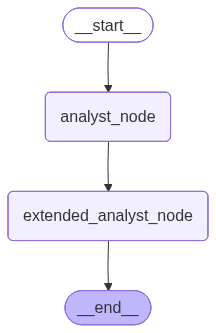

In [3]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print(graph.get_graph().draw_ascii())

In [ ]:
from langgraph.checkpoint.memory import MemorySaver

query = """
    Во вложении датасет, который описывает данные банковских клиентов.
    Необходимо решить задачу бинарной классификации, таргетом выступает столбец Default_Status
    Уникальный идентификатор клиента - Application ID
"""

graph = builder.compile(checkpointer=MemorySaver())

result = graph.invoke(
    {"messages": [HumanMessage(content=query)], "file_path": "test_data/Train_Set_90621.parquet"},
    config={"configurable": {"thread_id": "test_routing"}}
)

In [5]:
result

{'messages': [HumanMessage(content='\n    Во вложении датасет, который описывает данные банковских клиентов.\n    Необходимо решить задачу бинарной классификации, таргетом выступает столбец Default_Status\n    Уникальный идентификатор клиента - Application ID\n', additional_kwargs={}, response_metadata={}, id='0e92a3f3-ff21-4850-ab54-55d5210058b3'),
  AIMessage(content='По данным заявок на бизнес-кредит требуется предсказать вероятность/класс дефолта по заявке. В датасете представлены параметры банка и бизнеса (ставка, срок, сумма, занятость, документы и т.п.), а целевая переменная — Default_Status. Данные содержат как числовые, так и категориальные (замаскированные) признаки, связанные с конкретной заявкой.', additional_kwargs={}, response_metadata={}, id='3ac312d9-9ac6-49ef-bf9a-73c5dfb20c07', tool_calls=[], invalid_tool_calls=[])],
 'file_path': 'test_data/Train_Set_90621.parquet',
 'analysis_result': AnalysisResult(task_type=<TaskType.CLASSIFICATION: 'classification'>, target_colum